In [1]:

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [28]:
df = pd.read_csv("output/training_data.csv")


In [29]:
COL_SALE_DATE  = "SALE DATE"
df[COL_SALE_DATE] = pd.to_datetime(df[COL_SALE_DATE], errors='coerce')

In [30]:
# Extract year and month
df['year'] = df[COL_SALE_DATE].dt.year
df['month'] = df[COL_SALE_DATE].dt.month


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262933 entries, 0 to 263299
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   SALE DATE   262933 non-null  datetime64[ns]
 1   BLOCK       262933 non-null  int64         
 2   LOT         262933 non-null  int64         
 3   YEAR BUILT  262933 non-null  int64         
 4   ZIP CODE    262933 non-null  int64         
 5   SALE PRICE  262933 non-null  int64         
 6   year        262933 non-null  int32         
 7   month       262933 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(5)
memory usage: 16.0 MB


In [40]:
sum(df.duplicated(df.columns))

2222

In [41]:
#Delete the duplicates and check that it worked
df = df.drop_duplicates(df.columns, keep='last')
sum(df.duplicated(df.columns))

0

In [42]:
df.describe()

,SALE DATE,BLOCK,LOT,YEAR BUILT,ZIP CODE,SALE PRICE,year,month
count,260711,260711.000000,260711.00000,260711.00000,260711.000000,2.607110e+05,260711.000000,260711.000000
mean,2010-06-12 02:07:47.966445568,1124.538773,767.69350,1586.52391,10029.952096,1.839609e+06,2009.943224,6.531769
min,2003-01-01 00:00:00,5.000000,1.00000,0.00000,10001.000000,1.000700e+04,2003.000000,1.000000
25%,2006-05-15 00:00:00,850.000000,31.00000,1908.00000,10014.000000,4.286180e+05,2006.000000,4.000000
50%,2010-01-13 00:00:00,1158.000000,1007.00000,1930.00000,10021.000000,7.585960e+05,2010.000000,7.000000
75%,2014-07-10 00:00:00,1444.000000,1220.00000,1965.00000,10027.000000,1.525000e+06,2014.000000,9.000000
max,2018-11-30 00:00:00,2250.000000,9117.00000,2017.00000,10463.000000,4.111112e+09,2018.000000,12.000000
std,NaN,496.951736,852.73313,760.96387,38.183814,1.757092e+07,4.612251,3.322044


In [32]:
# Filter out empty zip codes
df = df[df['ZIP CODE'] != 0.]

In [33]:

X_df = df[['year', 'month', 'BLOCK', 'LOT', 'YEAR BUILT', 'ZIP CODE']]
Y_df = df[['SALE PRICE']]   # Target

<class 'pandas.core.frame.DataFrame'>
Index: 262933 entries, 0 to 263299
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   year        262933 non-null  int32
 1   month       262933 non-null  int32
 2   BLOCK       262933 non-null  int64
 3   LOT         262933 non-null  int64
 4   YEAR BUILT  262933 non-null  int64
 5   ZIP CODE    262933 non-null  int64
dtypes: int32(2), int64(4)
memory usage: 12.0 MB


In [10]:
# X = torch.cat((tensor_date.unsqueeze(1), temp), dim=1)
X = torch.nn.functional.normalize(torch.tensor(X_df.values, dtype=torch.float32 ), dim=0)
X

tensor([[1.9551e-03, 2.6529e-03, 5.9639e-04, 4.0862e-05, 2.1048e-03, 1.9462e-03],
        [1.9551e-03, 1.5918e-03, 5.9798e-04, 1.1237e-04, 2.1037e-03, 1.9462e-03],
        [1.9551e-03, 1.5918e-03, 6.3288e-04, 1.8745e-03, 2.1657e-03, 1.9462e-03],
        ...,
        [1.9541e-03, 2.6529e-03, 3.4578e-03, 2.1538e-03, 2.2189e-03, 1.9508e-03],
        [1.9541e-03, 2.6529e-04, 3.4578e-03, 2.0499e-03, 2.2189e-03, 1.9508e-03],
        [1.9541e-03, 1.8571e-03, 3.4578e-03, 2.0772e-03, 2.2189e-03, 1.9508e-03]])

In [11]:
Y = torch.nn.functional.normalize(torch.tensor(Y_df.values, dtype=torch.float32), dim=0)
Y

tensor([[4.1810e-04],
        [3.2119e-04],
        [7.7472e-04],
        ...,
        [9.3033e-05],
        [3.3226e-06],
        [5.5377e-06]])

In [12]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [13]:
y_train

tensor([[7.7528e-04],
        [2.4811e-04],
        [1.3844e-03],
        ...,
        [3.7180e-04],
        [1.2515e-04],
        [2.7583e-06]])

In [14]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


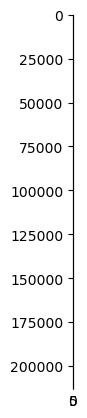

In [26]:
# create a sample tensor
# data = torch.randn(3, 3)

# plot the tensor using Matplotlib
plt.imshow(X_train.cpu())
plt.show()

In [15]:
# Use the nn package to define our model as a sequence of layers. nn.Sequential
# is a Module which contains other Modules, and applies them in sequence to
# produce its output. The Linear Module computes output from input using a
# linear function, and holds internal Tensors for its weight and bias.
# The Flatten layer flatens the output of the linear layer to a 1D tensor,
# to match the shape of `y`.
model = torch.nn.Sequential(
    torch.nn.Linear(6, 1),
    # torch.nn.Flatten(0, 1)
)

model = model.to(device)


In [16]:
@torch.no_grad
def compute_test_loss(model, X_test, y_test):
    
    loss_fn = torch.nn.MSELoss(reduction='sum')

    n = X_test.shape[0]
    
    for t in range(n):
        xx = X_test[t] 
        y = y_test[t]
        
        # predict
        y_pred = model(xx)
        loss = loss_fn(y_pred, y)
        # if t % 1000 == 0:
            # print(t, loss.item())

    return loss.item()
    

In [17]:

# The nn package also contains definitions of popular loss functions; in this
# case we will use Mean Squared Error (MSE) as our loss function.
loss_fn = torch.nn.MSELoss(reduction='sum')

learning_rate = 1e-6
n = X_train.shape[0]
for t in range(n):

    xx = X_train[t]
    
    y = y_train[t]
    
    # Forward pass: compute predicted y by passing x to the model. Module objects
    # override the __call__ operator so you can call them like functions. When
    # doing so you pass a Tensor of input data to the Module and it produces
    # a Tensor of output data.
    y_pred = model(xx)
    
    # Compute and print loss. We pass Tensors containing the predicted and true
    # values of y, and the loss function returns a Tensor containing the
    # loss.
    loss = loss_fn(y_pred, y)
    if t % 10000 == 0:
        print(t, loss.item())
        test_loss = compute_test_loss(model, X_test, y_test)
        print(f"Test Loss: {test_loss}")

    # Zero the gradients before running the backward pass.
    model.zero_grad()

    # Backward pass: compute gradient of the loss with respect to all the learnable
    # parameters of the model. Internally, the parameters of each Module are stored
    # in Tensors with requires_grad=True, so this call will compute gradients for
    # all learnable parameters in the model.
    loss.backward()

    # Update the weights using gradient descent. Each parameter is a Tensor, so
    # we can access its gradients like we did before.
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad

# You can access the first layer of `model` like accessing the first item of a list
linear_layer = model[0]


0 0.010337820276618004
Test Loss: 0.010293704457581043
10000 1684.8271484375
Test Loss: 1685.2364501953125
20000 1693.9832763671875
Test Loss: 1694.203369140625
30000 1646.0821533203125
Test Loss: 1646.0589599609375
40000 1819.0430908203125
Test Loss: 1818.2459716796875
50000 1850.9039306640625
Test Loss: 1850.9781494140625
60000 1721.077392578125
Test Loss: 1722.93017578125
70000 1684.43505859375
Test Loss: 1685.3662109375
80000 1696.753662109375
Test Loss: 1698.230712890625
90000 1784.345703125
Test Loss: 1783.1102294921875
100000 1697.2935791015625
Test Loss: 1701.8853759765625
110000 1746.292236328125
Test Loss: 1747.2696533203125
120000 1680.132080078125
Test Loss: 1683.89404296875
130000 1549.0435791015625
Test Loss: 1551.7623291015625
140000 1736.08544921875
Test Loss: 1742.8994140625
150000 1725.1771240234375
Test Loss: 1726.1015625
160000 1806.4737548828125
Test Loss: 1818.1971435546875
170000 1691.5281982421875
Test Loss: 1692.7080078125
180000 1756.7591552734375
Test Loss: 1

In [18]:

# For linear layer, its parameters are stored as `weight` and `bias`.
print(f'Result:  bias = {linear_layer.bias.item()} + weight {linear_layer.weight} ')

Result:  bias = -42.87871170043945 + weight Parameter containing:
tensor([[35.8035, 31.7470, 32.9041, 24.1057, 32.1869, 35.6627]],
       device='mps:0', requires_grad=True) 


In [19]:
linear_layer.bias.item()


-42.87871170043945

In [20]:
linear_layer.weight

Parameter containing:
tensor([[35.8035, 31.7470, 32.9041, 24.1057, 32.1869, 35.6627]],
       device='mps:0', requires_grad=True)

In [21]:
# Original mean and standard deviation
mean = torch.mean(df, dim=0)
stddev = torch.std(df, dim=0)

TypeError: mean() received an invalid combination of arguments - got (DataFrame, dim=int), but expected one of:
 * (Tensor input, *, torch.dtype dtype)
 * (Tensor input, tuple of ints dim, bool keepdim, *, torch.dtype dtype, Tensor out)
 * (Tensor input, tuple of names dim, bool keepdim, *, torch.dtype dtype, Tensor out)


In [ ]:
mean